# Hate Speech Detection with Sentinel: Building and Evaluating a Robust Detection Model

This example demonstrates how to use the Sentinel library to build a robust hate speech detection model with minimal examples and evaluate it across different content sources. Sentinel excels at detecting extremely rare classes of harmful content using contrastive learning principles.

## Data Sources and Methodology

### Training Data:
- **Positive Examples (~1,500)**: Extracted from the Southern Poverty Law Center's (SPLC) Extremist Files database, specifically from "In Their Own Words" sections that contain direct quotes from individuals or groups identified as extremists. These quotes represent authentic examples of hate speech from various extremist ideologies.
- **Negative Examples (~15,000)**: Obtained from the Lex Fridman podcast dataset, which contains neutral, intellectual discussions. The 10:1 ratio of negative-to-positive examples reflects the typical imbalance in real-world content.

### Evaluation Data:
- **Test Positives**: Podcast transcripts, known for controversial and potentially harmful content.
- **Test Negatives**: Different episodes from Lex Fridman's podcast, providing a contrast to potentially harmful content.

### Workflow:
1. **Data Preparation**: Extract extremist quotes from SPLC and neutral content from conversational datasets. Segment longer texts into manageable chunks of 512 tokens with 128-token stride.
2. **Model Building**: Create embeddings of both positive and negative examples using the MiniLM-L6-v2 model, then build a Sentinel index to measure semantic similarity to the hate speech class.
3. **Evaluation**: Score content at both segment and episode levels using contrastive learning and statistical measures like skewness to identify patterns across observations.
4. **Analysis**: Compare the distribution of hate speech affinity scores between a controversial podcast and Lex Fridman content to validate the model's effectiveness.

This approach demonstrates how Sentinel can detect rare patterns of concerning content with limited training examples, focusing on the semantic similarity to known extremist language rather than requiring extensive labeled datasets.

## Setup

Before running this notebook, ensure you have installed the example dependencies and registered the Poetry environment as a Jupyter kernel. See the project README for details.

### Downloading the data

There is a script for downloading the Extremist Files from the Southern Poverty Law Center (SPLC) website, the neutral dataset, and the controversial podcast examples

In [1]:
import os
import glob
import pandas as pd
from sentinel import SentinelLocalIndex
import re
from pathlib import Path
from tqdm.notebook import tqdm
import random
import pandas as pd
from tqdm.notebook import tqdm
import os
import requests
from datasets.utils.file_utils import get_datasets_user_agent

In [2]:
from transformers import AutoTokenizer

# Use MiniLM tokenizer
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def segment_text(text, max_tokens=512, stride=128):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    segments = []
    start = 0
    while start < len(tokens):
        end = start + max_tokens
        segment_tokens = tokens[start:end]
        segment_text = tokenizer.decode(segment_tokens)
        segments.append(segment_text)
        if end >= len(tokens):
            break
        start += stride
    return segments

## Download and parse the positive example
Let's build the hate speech dataset using the example from Southern Poverty Law Center's (SPLC)


In [3]:
# Define function to extract "In Their Own Words" sections from markdown files using line-by-line parsing
def extract_in_their_own_words(md_file):
    try:
        # Extract filename to use as identifier
        filename = Path(md_file).stem
        
        # Read the file line by line
        with open(md_file, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
        
        # Simple pattern to match "In his/her/their own words" headers
        own_words_pattern = re.compile(r'^(?:#+\s*)?[Ii]n (?:[Hh](?:is|er)|[Tt]heir) [Oo]wn [Ww]ords:?')
        background_pattern = re.compile(r'^(?:#+\s*)?(Background|BACKGROUND):?\s*$')
        
        # Variables to track state
        in_own_words_section = False
        current_section_lines = []
        all_paragraphs = []
        sections_found = 0
        
        # Process each line
        for i, line in enumerate(lines):
            line = line.strip()
            if not line:
                continue

            # Check if this is an "In their own words" heading
            starting_own_words_section = own_words_pattern.match(line)

            if starting_own_words_section:
                if in_own_words_section:
                    # This shouldnot happen. Print useful debug information
                    print(f"Warning: Found another 'In Their Own Words' section in {md_file} at line {i + 1}, but already in one.")
                    print(f"Previous section lines: {current_section_lines}")
                    current_section_lines = []  # Reset current section lines
                else:
                    in_own_words_section = True
                    sections_found += 1
                # Skip this line (heading) and start collecting content                
                continue
            
            # Check if we've reached a "Background" or another header section
            if in_own_words_section and (background_pattern.match(line) or (line.startswith('#') and len(line) > 1)):
                # Process the current section
                paragraphs = process_section(current_section_lines)
                all_paragraphs.extend({'filename': filename, 'paragraph': p} for p in paragraphs)
                current_section_lines = []
                in_own_words_section = False
                continue
            
            # If we're in a section, collect the line
            if in_own_words_section:
                current_section_lines.append(line)
        
        # Don't forget to process the last section if we're still in one at the end of the file
        if current_section_lines:
            if not in_own_words_section:
                print(f"Warning: Reached end of file in {md_file} without closing 'In Their Own Words' section.")
                print(f"Collected lines: {current_section_lines}")
            paragraphs = process_section(current_section_lines)
            all_paragraphs.extend({'filename': filename, 'paragraph': p} for p in paragraphs)
        
        # if sections_found > 0:
        #     print(f"Processing {md_file}: found {sections_found} 'In Their Own Words' sections")
        
        return all_paragraphs
    except Exception as e:
        print(f"Error processing {md_file}: {e}")
        return []

# Helper function to process collected section lines into paragraphs
def process_section(lines):
    if not lines:
        return []
    
    # Skip if the first line starts with "Background" (table of contents)
    if lines and lines[0].strip().startswith("Background"):
        return []
    
    quotes = []
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Citation patterns - typically start with a dash, quote mark, or include a year/reference
        is_citation = False
        
        # Patterns that strongly indicate a citation rather than a quote
        if (
            re.match(r'^(—|â|\xa0?—|\xa0?–|"|â\x80\x94)$', line) or
            # Lines ending with a year
            re.search(r' \d{4}\.?\s*$', line)
        ) and len(line) < 100:
            # If it looks like a citation, skip it
            is_citation = True
        
        # If not a citation, add as a quote
        if not is_citation:
            quotes.append(line)
    
    # Filter out very short quotes (likely fragments)
    quotes = [q for q in quotes if len(q) > 10]
    
    return quotes

# Find all markdown files in the SPLC Extremist Files scraped dataset directory
splc_data_dir = "data/splc_extremist_files"
md_files = []
if os.path.exists(splc_data_dir):
    md_files = glob.glob(os.path.join(splc_data_dir, "**", "*.md"), recursive=True)
    print(f"Found {len(md_files)} markdown files.")
else:
    print("Dataset directory not found. Please run the download cell first.")

# If we find markdown files, extract "In Their Own Words" sections
if md_files:
    # Process all markdown files and collect paragraphs
    all_paragraphs = []
    for md_file in tqdm(md_files, desc="Processing markdown files"):
        paragraphs = extract_in_their_own_words(md_file)
        all_paragraphs.extend(paragraphs)
    
    # Create a DataFrame from the extracted paragraphs
    own_words_df = pd.DataFrame(all_paragraphs)
    
    if not own_words_df.empty:
        print(f"Extracted {len(own_words_df)} paragraphs from 'In Their Own Words' sections.")
        
    else:
        print("No 'In Their Own Words' sections found in the markdown files.")
else:
    print("No markdown files found.")

Found 249 markdown files.


Previous section lines: ['Background: ‘Shock jock’ and violent rhetoric', '‘Beginning To Talk Like Us:’ Walsh’s white supremacist rhetoric', 'Targeting children’s hospitals', 'Matt Walsh is a blogger and talk show host for the Daily Wire website. He frequently demonizes LGBTQ+ people and promotes racist and anti-transgender conspiracy theories. Walsh leads a campaign against gender-affirming health care that has targeted American hospitals with harassment and has advocated executing doctors who provide health care to transgender people. Walsh is also known for perpetuating the notion of anti-white racism, which is grounded in white supremacy, and spreading conspiracy theories about supposed campaigns of anti-white violence.', 'Walsh is a self-described “', 'theocratic fascist', '” who is one of the most prominent anti-transgender voices in American right-wing media. Walsh sometimes suggests his most extreme comments are satirical or in jest, as when he explained why he describes himsel

In [4]:
# Remove quotes from files that produced too many quotes, since these are probably malformatted and the extraction failed
files_with_too_many_quotes = own_words_df['filename'].value_counts()[own_words_df['filename'].value_counts() > 100].index.tolist()
print(f"Removing {len(files_with_too_many_quotes)} files with too many quotes: {files_with_too_many_quotes}")
own_words_df = own_words_df[~own_words_df['filename'].isin(files_with_too_many_quotes)]

Removing 5 files with too many quotes: ['tucker-carlson', 'center-immigration-studies', 'matt-walsh', 'mike-cernovich', 'paul-nehlen']


In [5]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

print(f"DataFrame shape: {own_words_df.shape}")
print("Random 30 rows:")
display(own_words_df.sample(30, random_state=42))

# Display unique filenames to see how many different extremists were extracted
print(f"\nNumber of unique extremists: {own_words_df['filename'].nunique()}")
print("Unique extremist quotes:")

print(own_words_df['filename'].value_counts())

if 8 != len(own_words_df[own_words_df["filename"] == "daryush-roosh-valizadeh"]):
    print("ERROR: Expected 8 quotes for Daryush Roosh Valizadeh, including one very long citation (117 characters).")
    display(own_words_df[own_words_df["filename"] == "daryush-roosh-valizadeh"])


pd.set_option("display.max_colwidth", 500)
pd.set_option("display.max_rows", 10)


DataFrame shape: (1516, 2)
Random 30 rows:


,filename,paragraph
51,richard-bertrand-spencer,"“We’re going to be back here, and we’re going to humiliate all of these people who opposed us. We’ll be back here 1,000 times if necessary. I always win. Because I have the will to win, I keep going until I win.”"
168,tim-wildmon,"â[Islam] is in fact a religion of war, violence, intolerance, and physical persecution of non-Muslims.â"
2468,misogynist-incels,“Jews heavily pushed feminism. Roasties have such high standards because they are ‘liberated’. You probably would have gotten your d*** wet by now if it weren’t for feminism and for Jews.”
1040,kyle-bristow,â Quoted in the
422,raymond-cattell,"âSuppose, as may well be the case, that one of these races is naturally courageous, self-sacrificing and enterprising and the other less so. The group will continue to prosper owing to the activities of inventors and explorers of the first race, who, as is generally the rule, will not pass on the usual number of children to the next generation. The nation will be successful in war because the same race has actively responded to the call to arms and to self-sacrifice. Throughout these activities, this first race will on an average be giving more to the group than it can itself recoup. Eventually only the second race will inherit the group advantages acquired largely by the first racial compound. Then like a huge parasite which has devoured its host, will the nation be bereft of all the qualities that gave it power, remain a monstrous frustration of evolution, a biological abortion able in virtue of its inherited wealth, to do untold damage to neighboring races naturally more capable. The hatred and abhorrence which many peoples feel for the Jewish (and to some extent Mongolian) practice of living in other nations, instead of forming an independent, self-sustained group of their own, comes from a deep intuitive feeling that somehow it is not âplaying the game.â Because our unbiologically-minded civilization cannot perceive or appreciate any intellectual causes for these feelings they are readily branded as âprejudiceâ by would-be intellectuals.â"
1479,joseph-francis-farah,Polygamy? Sure.
585,bill-white,â Headline for 2008 article about then-presidential candidate Barack Obama who was depicted in the middle of a rifle scope on the cover of White’s American National Socialist Workers Party’s magazine
220,lydia-brimelow,"âAs the President of the VDARE Foundation, I work alongside my husband, Editor of VDARE.com, Peter Brimelow, to defeat the post-1964 Immigration Act disaster that has set America on a course of destruction.â"
2467,misogynist-incels,"– Comment on an incel forum post titled “‘They are animals…’ ER was right,”"
2439,james-lindsay,"If anyone causes one of these little onesâthose who believe in meâto stumble, it would be better for them to have a large millstone hung around their neck and to be drowned in the depths of the sea.â)"



Number of unique extremists: 154
Unique extremist quotes:
stefan-molyneux                                  28
robert-spencer                                   24
gays-against-groomers                            24
greg-johnson                                     24
jack-posobiec                                    23
james-lindsay                                    23
veterans-patrol                                  22
roy-moore                                        22
alex-jones                                       21
faith-education-commerce                         20
family-research-council                          19
august-kreis                                     19
act-america                                      19
moms-liberty                                     19
pamela-geller                                    18
proud-boys                                       17
lieutenant-general-william-g-jerry-boykin-ret    17
david-yerushalmi                                 17
richa

In [6]:
# Check token counts for some paragraphs
token_counts = []
for _, row in own_words_df.iterrows():
    tokens = tokenizer.encode(row['paragraph'], add_special_tokens=False)
    token_counts.append(len(tokens))

print(f"Max tokens in any paragraph: {max(token_counts)}")
print(f"Average tokens per paragraph: {sum(token_counts)/len(token_counts):.1f}")
print(f"Number of paragraphs exceeding 512 tokens: {sum(1 for count in token_counts if count > 512)}")

# Check the longest paragraphs
longest_idx = token_counts.index(max(token_counts))
print(f"\nLongest paragraph ({token_counts[longest_idx]} tokens):")
print(own_words_df.iloc[longest_idx]['paragraph'][:200] + "...")

Max tokens in any paragraph: 322
Average tokens per paragraph: 49.7
Number of paragraphs exceeding 512 tokens: 0

Longest paragraph (322 tokens):
“Only one conclusion is possible… . [T]he broad picture is clear and inescapable: at some point in the foreseeable future the white British people will become a minority in these islands, and whites w...


In [7]:
# Apply segmentation to each quote in own_words_df
segmented_rows = []
for idx, row in own_words_df.iterrows():
    segments = segment_text(row['paragraph'])
    for i, segment in enumerate(segments):
        segmented_rows.append({
            'filename': row['filename'],
            'paragraph_segment': segment,
            'segment_id': i,
            'label': 1  # positive example
        })

segmented_df = pd.DataFrame(segmented_rows)
print(f"Segmented dataset shape: {segmented_df.shape}")
display(segmented_df.sample(33, random_state=42))

Segmented dataset shape: (1516, 4)


,filename,paragraph_segment,segment_id,label
51,richard-bertrand-spencer,"“ we ’ re going to be back here, and we ’ re going to humiliate all of these people who opposed us. we ’ ll be back here 1, 000 times if necessary. i always win. because i have the will to win, i keep going until i win. ”",0,1
168,tim-wildmon,"a [ islam ] is in fact a religion of war, violence, intolerance, and physical persecution of non - muslims. a",0,1
1469,misogynist-incels,“ jews heavily pushed feminism. roasties have such high standards because they are ‘ liberated ’. you probably would have gotten your d * * * wet by now if it weren ’ t for feminism and for jews. ”,0,1
926,kyle-bristow,a quoted in the,0,1
422,raymond-cattell,"asuppose, as may well be the case, that one of these races is naturally courageous, self - sacrificing and enterprising and the other less so. the group will continue to prosper owing to the activities of inventors and explorers of the first race, who, as is generally the rule, will not pass on the usual number of children to the next generation. the nation will be successful in war because the same race has actively responded to the call to arms and to self - sacrifice. throughout these act...",0,1
...,...,...,...,...
1164,craig-cobb,"anov. 16, 2013, videotaped rant against a resident while apatrollinga the streets of leith",0,1
677,family-research-council,"“ the reality is, homosexuals have entered the scouts in the past for predatory purposes. ”",0,1
123,base,"“ most of our members are national socialists and / or fascists, although we also have some run - of - the - mill white nationalists … we have a strong revolutionary and militant current running through the base. most of our members are pretty hardcore in that sense. you ’ re going to be stepping into probably the most extreme group of pro - white people that you can probably come across. ” –",0,1
706,scott-lively,“ the gay movement is an evil institution [ whose ] goal is to defeat the marriage - based society and replace it with a culture of sexual promiscuity in which thereas no restrictions on sexual conduct except the principle of mutual choice. ”,0,1


### Download the Neutral example 
Download the neutral dataset from hugging face.

In [8]:
# ============================================================================
# ORIGINAL CODE (kept for reference, commented out).
# It failed with "poetry: command not found" because a %%bash cell starts a
# plain non-login shell that never reads ~/.zshrc, so ~/.local/bin (where
# poetry is installed) is missing from PATH.
# ============================================================================
# %%bash
# # Change directory into the 'scripts' folder
# cd scripts
#
# # Run your Python script using poetry run
# # This ensures all your Poetry-managed dependencies are available
# poetry run python fetch-neutral-examples-data.py
#
# # The script will create two files:
# # 1. `neutral-segments-training.csv`: Contains ~15,000 individual segments (10x our positive examples) for training
# # 2. `neutral-episodes-eval.parquet`: Contains 30 full episodes for evaluation
# # You can customize the number of segments and evaluation episodes:
# # ```bash
# # python fetch-neutral-examples-data.py -n 20000 -e 50  # 20k segments, 50 eval episodes
# # ```

# ============================================================================
# WORKING VERSION
# ============================================================================
import sys

# This notebook's kernel already runs inside the Poetry virtualenv
# (Sentinel/.venv), so sys.executable has every dependency the script needs and
# the `poetry run` wrapper is unnecessary.
print("Running with:", sys.executable)

# The script writes two files into examples/data/ :
#   1. neutral-segments-training.csv -> ~15,000 individual segments for training
#   2. neutral-episodes-eval.parquet -> 30 full episodes for evaluation
# To change those amounts, append flags, e.g. `... -n 20000 -e 50`
!cd scripts && {sys.executable} fetch-neutral-examples-data.py

Running with: ~/workspace/Sentinel/.venv/bin/python


Loading neutral podcast dataset directly from Hugging Face...
Using cached file at ~/.cache/huggingface/neutral/lex-fridman-podcastUsing cached file.parquet
Successfully loaded data with 346 rows
Processed 346 episodes with segments
Extracting segments: 100%|█████████████████| 316/316 [00:00<00:00, 3296.62it/s]
Collected 761946 segments before sampling
Randomly sampled 15000 segments
Saved 15000 training segments to neutral-segments-training.csv
Saved 30 evaluation episodes to neutral-episodes-eval.parquet


In [9]:
# Calculate how many negative examples we need (10x the number of positives)

# Seeded so the negative segments sampled below are the same on every run and
# the numbers reported later in the notebook stay comparable.
random.seed(42)

num_positives = len(segmented_df)
num_negatives = num_positives * 10
print(f"Number of positive examples: {num_positives}")
print(f"Number of negative examples to extract: {num_negatives}")

# Function to download and read parquet file
def load_neutral_examplest_dataset():
    try:
        print("Loading neutral podcast dataset directly from Hugging Face...")
        # Direct download of the parquet file
        url = "https://huggingface.co/datasets/Whispering-GPT/lex-fridman-podcast/resolve/main/data/train-00000-of-00001-25f40520d4548308.parquet"
        
        # Create cache directory
        cache_dir = os.path.join(os.path.expanduser("~"), ".cache", "huggingface", "lex-fridman-podcast")
        os.makedirs(cache_dir, exist_ok=True)
        
        # Download the file if it doesn't exist
        local_path = os.path.join(cache_dir, "neutral-episodes-eval.parquet")
        
        if not os.path.exists(local_path):
            print(f"Downloading parquet file to {local_path}...")
            response = requests.get(url, stream=True)
            response.raise_for_status()
            
            with open(local_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print("Download complete!")
        else:
            print(f"Using cached file at {local_path}")
            
        # Read the parquet file with pandas
        df = pd.read_parquet(local_path)
        print(f"Successfully loaded data with {len(df)} rows")
        
        # Convert to proper format for our code
        podcast_data = []
        for _, row in df.iterrows():
            if 'segments' in row:
                episode = {"segments": []}
                # Process segments
                for segment in row['segments']:
                    if isinstance(segment, dict) and 'text' in segment and segment['text']:
                        episode["segments"].append({"text": segment['text']})
                podcast_data.append(episode)
        
        print(f"Processed {len(podcast_data)} episodes with segments")
        return podcast_data
    
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

# Load the Neutral podcast dataset
neutral_dataset = load_neutral_examplest_dataset()

print(f"Dataset loaded with {len(neutral_dataset)} episodes")

# Function to extract random segments from the dataset
def extract_random_segments(dataset, num_segments):
    all_segments = []
    
    # Iterate through episodes
    for episode in tqdm(dataset, desc="Extracting segments"):
        if "segments" in episode and episode["segments"]:
            # Extract text from random segments in this episode
            episode_segments = episode["segments"]
            # Take some random segments from this episode
            num_to_take = len(episode_segments)
            if num_to_take > 0:
                random_segments = random.sample(episode_segments, num_to_take)
                for segment in random_segments:
                    if "text" in segment and segment["text"]:
                        all_segments.append(segment["text"])
    
    print(f"Collected {len(all_segments)} segments before sampling")
    
    # If we have more segments than needed, randomly sample
    if len(all_segments) > num_segments:
        all_segments = random.sample(all_segments, num_segments)
    elif len(all_segments) < num_segments:
        print(f"Warning: Could only collect {len(all_segments)} segments, fewer than the requested {num_segments}")
        
    return all_segments

# Extract random segments
print("Extracting random segments...")
negative_samples = extract_random_segments(neutral_dataset, num_negatives)

# Create a DataFrame with the negative examples structured like segmented_df
# The segmented_df has 'filename', 'paragraph_segment', 'segment_id', 'label'
negative_df = pd.DataFrame({
    'filename': ['neutral_podcast'] * len(negative_samples),
    'paragraph_segment': negative_samples,  # Using paragraph_segment to match positive df
    'segment_id': range(len(negative_samples)),  # Adding segment_id
    'label': [0] * len(negative_samples)  # 0 for negative examples
})

# Display some statistics
print(f"Extracted {len(negative_samples)} negative examples")
print("\nSample of negative examples:")
display(negative_df.head(5))

# Create a combined dataset
combined_df = pd.concat([segmented_df, negative_df], ignore_index=True)
print(f"\nCombined dataset shape: {combined_df.shape}")
print("Sample of combined dataset:")
display(combined_df.sample(50, random_state=42))

Number of positive examples: 1516
Number of negative examples to extract: 15160
Loading neutral podcast dataset directly from Hugging Face...
Using cached file at ~/.cache/huggingface/lex-fridman-podcast/neutral-episodes-eval.parquet
Successfully loaded data with 346 rows
Processed 346 episodes with segments
Dataset loaded with 346 episodes
Extracting random segments...


Collected 832839 segments before sampling
Extracted 15160 negative examples

Sample of negative examples:


,filename,paragraph_segment,segment_id,label
0,neutral_podcast,and gave people a big massive lesson in civics.,0,0
1,neutral_podcast,I'm humiliated about that kind of stuff,1,0
2,neutral_podcast,I don't know.,2,0
3,neutral_podcast,"Yeah, like it made me imagine",3,0
4,neutral_podcast,"but people love it when I ask it,",4,0



Combined dataset shape: (16676, 4)
Sample of combined dataset:


,filename,paragraph_segment,segment_id,label
4990,neutral_podcast,Really?,3474,0
3781,neutral_podcast,If land wars turn into an inescapable quagmire each time,2265,0
11523,neutral_podcast,"And for the military, in some sense,",10007,0
47,hal-turner,"on june 3, 2009, turner was arrested and charged with inciting injury to persons or property. in a blog post, he had asked connecticut catholics to “ take up arms ” against two lawmakers and an employee of the office of state ethics. turner also threatened to release the home addresses of these three men. a jury acquitted turner of the charges in september 2011.",0,1
13262,neutral_podcast,"through that decision tree that Ryan was presenting,",11746,0
...,...,...,...,...
99,roy-moore,"“ we were torn apart in the civil war — brother against brother, north against south, party against party.. what changed? now we have blacks and whites fighting, reds and yellows fighting, democrats and republicans fighting, men and women fighting. ” — speaking at a rally in florence, alabama, september,",0,1
2857,neutral_podcast,Right.,1341,0
3115,neutral_podcast,"Yeah, so if you dig in on the idea of this reference frame,",1599,0
4972,neutral_podcast,an important moment in human history.,3456,0


## Build The Indexes
Using the 2 datasets we have loaded, we will build the negative and positive index used by sentinel

In [10]:
# Create a Sentinel hate speech detection index using our own data
import torch
from sentinel.sentinel_local_index import SentinelLocalIndex
from sentinel.embeddings.sbert import get_sentence_transformer_and_scaling_fn

# Initialize sentence model and get scaling function
model_name = "all-MiniLM-L6-v2"
model, scale_fn = get_sentence_transformer_and_scaling_fn(model_name)

# Prepare examples
print("Extracting positive and negative examples...")
positive_examples = segmented_df['paragraph_segment'].tolist()  # From extremists (hate speech)
negative_examples = negative_df['paragraph_segment'].tolist()  # From neutral podcast (neutral speech)

print(f"Number of positive examples: {len(positive_examples)}")
print(f"Number of negative examples: {len(negative_examples)}")

# Encode examples
print("\nEncoding positive examples...")
positive_embeddings = model.encode(positive_examples, normalize_embeddings=True)
positive_embeddings = torch.tensor(positive_embeddings)

print("\nEncoding negative examples...")
negative_embeddings = model.encode(negative_examples, normalize_embeddings=True)
negative_embeddings = torch.tensor(negative_embeddings)

# Create the index
print("\nCreating Sentinel index...")
index = SentinelLocalIndex(
    sentence_model=model,
    positive_embeddings=positive_embeddings,
    negative_embeddings=negative_embeddings,
    scale_fn=scale_fn,
    positive_corpus=positive_examples,
    negative_corpus=negative_examples,
)

# Save locally
print("\nSaving index...")
save_path = "./hate_speech_model"
saved_config = index.save(path=save_path, encoder_model_name_or_path=model_name)
print(f"Saved index with encoder model: {saved_config.encoder_model_name_or_path}")

Extracting positive and negative examples...
Number of positive examples: 1516
Number of negative examples: 15160

Encoding positive examples...

Encoding negative examples...

Creating Sentinel index...

Saving index...
Saved index with encoder model: all-MiniLM-L6-v2


# Testing the New Sentinel Index
Let's use our new sentinel index to detect violation in podcast

In [11]:
%%bash
TARGET_DIR="data/podcast_examples"
REPO_URL="https://github.com/Fudge/infowars.git"

if [ -d "$TARGET_DIR" ]; then
  echo "The directory '$TARGET_DIR' already exists. Skipping git clone."
else
  echo "Cloning '$REPO_URL' into '$TARGET_DIR'..."
  git clone "$REPO_URL" "$TARGET_DIR"
  if [ $? -eq 0 ]; then
    echo "Cloning successful."
  else
    echo "Error: Git clone failed."
  fi
fi

The directory 'data/podcast_examples' already exists. Skipping git clone.


In [12]:
# List transcript files and load a sample for evaluation
data_dir = "data/podcast_examples"  # Define data_dir for this cell

# sorted() because glob returns filesystem order, which differs between machines.
# Without it the "first 100" episodes used below are not the same set twice.
transcript_files = sorted(glob.glob(os.path.join(data_dir, "transcripts", "**", "*.txt"), recursive=True))
print(f"Found {len(transcript_files)} transcript files.")

# Check if transcript files were found before trying to open one
if transcript_files:
    # Load the first transcript as an example
    with open(transcript_files[0], "r", encoding="utf-8", errors="ignore") as f:
        transcript_text = f.read()
else:
    print("No transcript files found. Please ensure the podcast_examples directory exists and contains transcript files.")
    # Set a placeholder to avoid errors in subsequent cells
    transcript_text = "No transcript available."

Found 10396 transcript files.


In [13]:
from sentinel.sentinel_local_index import SentinelLocalIndex
print("Loading saved Sentinel index...")
index = SentinelLocalIndex.load(path="./hate_speech_model")
print("Index loaded successfully!")

# Function to clean transcript text by removing time markers
def clean_transcript(text):
    # Remove [HH:MM:SS --> HH:MM:SS] time markers
    cleaned = re.sub(r'\[\d{2}:\d{2}:\d{2}\s*-->\s*\d{2}:\d{2}:\d{2}\]\s*', '', text)
    # Remove any remaining timestamps in similar formats
    cleaned = re.sub(r'\d{2}:\d{2}:\d{2}\s*->\s*\d{2}:\d{2}:\d{2}\s*', '', cleaned)
    return cleaned.strip()

# Take a random sample of 100 episodes rather than the first 100. The corpus
# is grouped by show, so an alphabetical slice would cover only the shows that
# sort first and would miss the rest entirely. Seeded so the same 100 episodes
# are drawn on every run.
random.seed(42)
selected_transcripts = random.sample(transcript_files, min(100, len(transcript_files)))

# Load and clean transcripts
cleaned_transcripts = []
for file_path in tqdm(selected_transcripts, desc="Processing transcripts"):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        cleaned_text = clean_transcript(text)
        cleaned_transcripts.append({
            'file': file_path,
            'text': cleaned_text
        })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

print(f"Processed {len(cleaned_transcripts)} transcripts")

# Segment the transcripts
all_segments = []
for transcript in tqdm(cleaned_transcripts, desc="Segmenting transcripts"):
    segments = segment_text(transcript['text'])
    for segment in segments:
        all_segments.append({
            'file': transcript['file'],
            'segment': segment
        })

print(f"Created {len(all_segments)} segments")

# Create a DataFrame from the segments
results_df = pd.DataFrame(all_segments)

# Group by file and calculate affinity scores for each episode
episode_results = {}
segment_scores_dict = {}

# Process each file's segments
for file_path, group in tqdm(results_df.groupby('file'), desc="Calculating rare class affinity"):
    segments = group['segment'].tolist()
    # Calculate hate speech affinity scores
    result = index.calculate_rare_class_affinity(segments)
    
    # Store episode-level score
    episode_results[file_path] = result.rare_class_affinity_score
    
    # Store individual segment scores
    for segment, score in result.observation_scores.items():
        # Create a tuple key to store both file and segment
        segment_scores_dict[(file_path, segment)] = score

# Create DataFrame for episode-level scores
episode_scores_df = pd.DataFrame({
    'file': list(episode_results.keys()),
    'hate_affinity_score': list(episode_results.values())
}).sort_values('hate_affinity_score', ascending=False)

# Create DataFrame for segment-level scores
segments_with_scores = []
for (file_path, segment), score in segment_scores_dict.items():
    segments_with_scores.append({
        'file': file_path,
        'segment': segment,
        'score': score
    })
segment_scores_df = pd.DataFrame(segments_with_scores)


Loading saved Sentinel index...


Index loaded successfully!


Processed 100 transcripts


Token indices sequence length is longer than the specified maximum sequence length for this model (77886 > 512). Running this sequence through the model will result in indexing errors


Created 52185 segments


In [14]:
# Now let's analyze Lex Fridman podcast episodes to compare with the other podcast
import logging
import numpy as np

# We'll reuse the same index we loaded earlier
print("Using the same Sentinel index for Lex Fridman podcasts...")

# Select 30 random episodes from the Lex Fridman dataset. Seeded so the same
# episodes are picked on every run.
random.seed(42)
num_neutral_episodes = min(30, len(neutral_dataset))
random_neutral_episodes = random.sample(neutral_dataset, num_neutral_episodes)
print(f"Selected {num_neutral_episodes} random Lex Fridman podcast episodes")

# Process the episodes similar to how we processed the transcripts
lex_cleaned_transcripts = []
for i, episode in enumerate(tqdm(random_neutral_episodes, desc="Processing Neutral episodes")):
    try:
        if "segments" in episode and episode["segments"]:
            # Join all segments to create a full transcript
            segments_text = " ".join([seg["text"] for seg in episode["segments"] if "text" in seg and seg["text"]])
            
            # Create a transcript entry with a unique identifier
            lex_cleaned_transcripts.append({
                'file': f"lex_fridman_episode_{i}",  # Create a unique identifier
                'text': segments_text
            })
    except Exception as e:
        print(f"Error processing Lex episode {i}: {e}")

print(f"Processed {len(lex_cleaned_transcripts)} Lex Fridman transcripts")

# Segment the transcripts
lex_all_segments = []
for transcript in tqdm(lex_cleaned_transcripts, desc="Segmenting Neutral transcripts"):
    segments = segment_text(transcript['text'])
    for segment in segments:
        lex_all_segments.append({
            'file': transcript['file'],
            'segment': segment
        })

print(f"Created {len(lex_all_segments)} segments from Lex Fridman podcasts")

# Create a DataFrame from the segments
lex_results_df = pd.DataFrame(lex_all_segments)

# Group by file and calculate affinity scores for each episode
lex_episode_results = {}
lex_segment_scores_dict = {}

# Process each file's segments
for file_path, group in tqdm(lex_results_df.groupby('file'), desc="Calculating rare class affinity for Neutral episodes"):
    segments = group['segment'].tolist()
    # Calculate hate speech affinity scores
    result = index.calculate_rare_class_affinity(segments)
    
    # Store episode-level score
    lex_episode_results[file_path] = result.rare_class_affinity_score
    
    # Store individual segment scores
    for segment, score in result.observation_scores.items():
        # Create a tuple key to store both file and segment
        lex_segment_scores_dict[(file_path, segment)] = score

# Create DataFrame for episode-level scores
lex_episode_scores_df = pd.DataFrame({
    'file': list(lex_episode_results.keys()),
    'hate_affinity_score': list(lex_episode_results.values())
}).sort_values('hate_affinity_score', ascending=False)


# Create DataFrame for segment-level scores
lex_segments_with_scores = []
for (file_path, segment), score in lex_segment_scores_dict.items():
    lex_segments_with_scores.append({
        'file': file_path,
        'segment': segment,
        'score': score
    })
lex_segment_scores_df = pd.DataFrame(lex_segments_with_scores)

Using the same Sentinel index for Lex Fridman podcasts...
Selected 30 random Lex Fridman podcast episodes


Processed 30 Lex Fridman transcripts


Created 7008 segments from Lex Fridman podcasts


Saved episode scores to CSV files:
- controversial_podcast.csv
- lex_fridman_episode_scores.csv
- all_platform_scores.csv


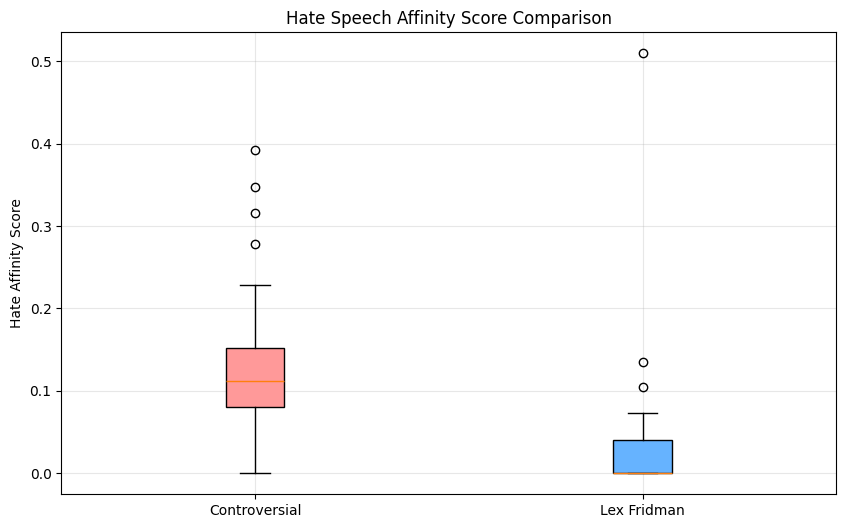

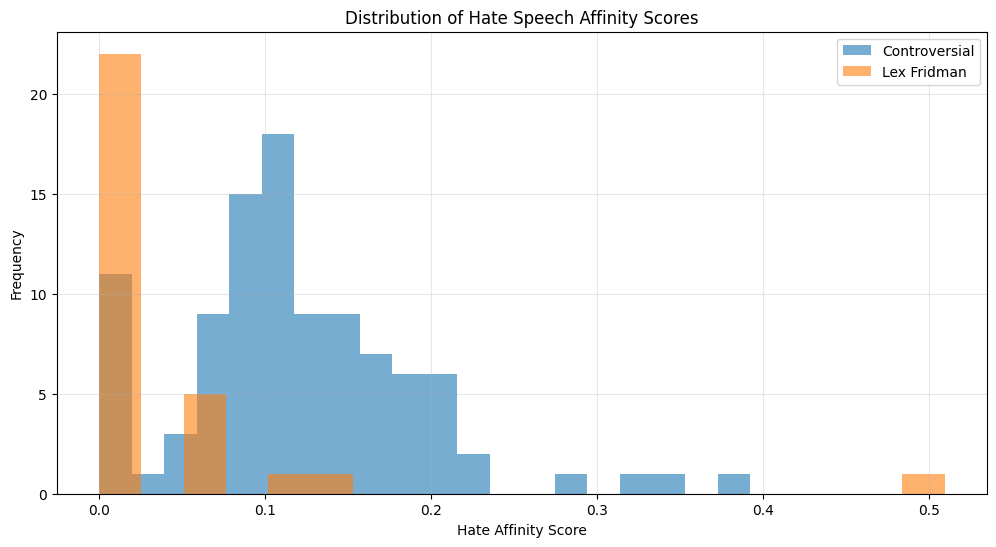


Statistics for hate affinity scores:

Controversial:
  Mean: 0.1185
  Median: 0.1118
  Std Dev: 0.0722
  Min: 0.0000
  Max: 0.3922

Lex Fridman:
  Mean: 0.0355
  Median: 0.0000
  Std Dev: 0.0967
  Min: 0.0000
  Max: 0.5095


In [15]:
# Create a comparison visualization of the hate affinity scores between the 2 pdocasts
import matplotlib.pyplot as plt
import numpy as np

# Save the dataframes to CSV files
episode_scores_df.to_csv("data/controversial_podcast.csv", index=False)
lex_episode_scores_df.to_csv("data/lex_fridman_episode_scores.csv", index=False)
print("Saved episode scores to CSV files:")
print("- controversial_podcast.csv")
print("- lex_fridman_episode_scores.csv")

# Create a combined dataset for comparison
controversial_scores = pd.DataFrame({
    'platform': ['Controversial'] * len(episode_scores_df),
    'hate_affinity_score': episode_scores_df['hate_affinity_score']
})

lex_scores = pd.DataFrame({
    'platform': ['Lex Fridman'] * len(lex_episode_scores_df),
    'hate_affinity_score': lex_episode_scores_df['hate_affinity_score']
})

all_scores = pd.concat([controversial_scores, lex_scores], ignore_index=True)
all_scores.to_csv("data/all_platform_scores.csv", index=False)
print("- all_platform_scores.csv")

# Create a boxplot comparison using matplotlib
plt.figure(figsize=(10, 6))

# Extract data for each platform
platforms = all_scores['platform'].unique()
data = [all_scores[all_scores['platform'] == platform]['hate_affinity_score'] for platform in platforms]

# Create box plot
box = plt.boxplot(data, patch_artist=True, labels=platforms)
colors = ['#ff9999', '#66b3ff']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Hate Speech Affinity Score Comparison')
plt.ylabel('Hate Affinity Score')
plt.grid(True, alpha=0.3)
plt.show()

# Create histograms to compare distributions
plt.figure(figsize=(12, 6))

# Extract data for each platform
for i, platform in enumerate(platforms):
    platform_data = all_scores[all_scores['platform'] == platform]['hate_affinity_score']
    plt.hist(platform_data, bins=20, alpha=0.6, label=platform)
    

plt.title('Distribution of Hate Speech Affinity Scores')
plt.xlabel('Hate Affinity Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print statistics summary
print("\nStatistics for hate affinity scores:")
for platform in all_scores['platform'].unique():
    platform_scores = all_scores[all_scores['platform'] == platform]['hate_affinity_score']
    print(f"\n{platform}:")
    print(f"  Mean: {platform_scores.mean():.4f}")
    print(f"  Median: {platform_scores.median():.4f}")
    print(f"  Std Dev: {platform_scores.std():.4f}")
    print(f"  Min: {platform_scores.min():.4f}")
    print(f"  Max: {platform_scores.max():.4f}")

In [16]:
# Save segment-level scores to CSV files for further analysis
segment_scores_df.to_csv("data/controversial_segment_scores.csv", index=False)
lex_segment_scores_df.to_csv("data/lex_fridman_segment_scores.csv", index=False)

print("Saved segment-level scores to CSV files:")
print("- controversial_segment_scores.csv")
print("- lex_fridman_segment_scores.csv")

# Count high risk segments in both datasets (score > 0.5)
controversial_high_risk = len(segment_scores_df[segment_scores_df['score'] > 0.5])
lex_high_risk = len(lex_segment_scores_df[lex_segment_scores_df['score'] > 0.5])

print(f"\nHigh risk segments (score > 0.5):")
print(f"- Controversial: {controversial_high_risk} segments ({controversial_high_risk/len(segment_scores_df)*100:.2f}% of all segments)")
print(f"- Lex Fridman: {lex_high_risk} segments ({lex_high_risk/len(lex_segment_scores_df)*100:.2f}% of all segments)")

# Count medium risk segments (score between 0.1 and 0.5)
controversial_medium_risk = len(segment_scores_df[(segment_scores_df['score'] > 0.1) & (segment_scores_df['score'] <= 0.5)])
lex_medium_risk = len(lex_segment_scores_df[(lex_segment_scores_df['score'] > 0.1) & (lex_segment_scores_df['score'] <= 0.5)])

print(f"\nMedium risk segments (0.1 < score <= 0.5):")
print(f"- Controversial: {controversial_medium_risk} segments ({controversial_medium_risk/len(segment_scores_df)*100:.2f}% of all segments)")
print(f"- Lex Fridman: {lex_medium_risk} segments ({lex_medium_risk/len(lex_segment_scores_df)*100:.2f}% of all segments)")

Saved segment-level scores to CSV files:
- controversial_segment_scores.csv
- lex_fridman_segment_scores.csv

High risk segments (score > 0.5):
- Controversial: 0 segments (0.00% of all segments)
- Lex Fridman: 0 segments (0.00% of all segments)

Medium risk segments (0.1 < score <= 0.5):
- Controversial: 976 segments (1.87% of all segments)
- Lex Fridman: 72 segments (1.03% of all segments)


Saved all segment-level data to CSV files


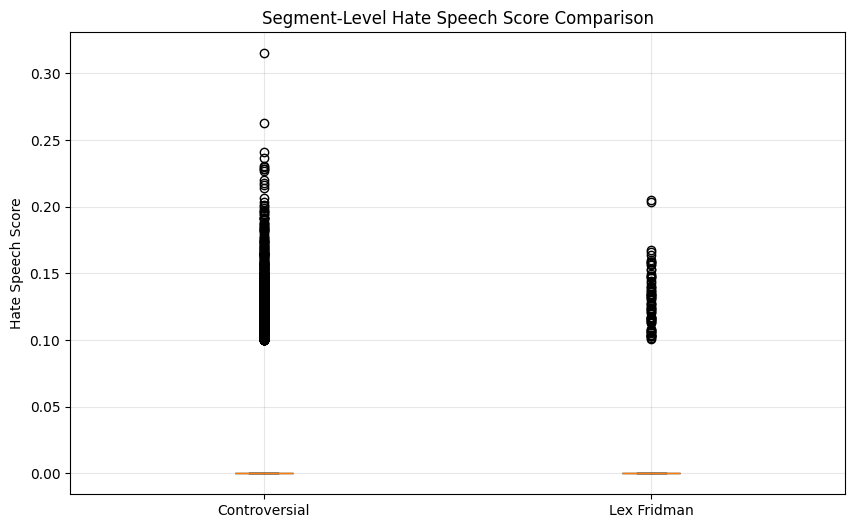

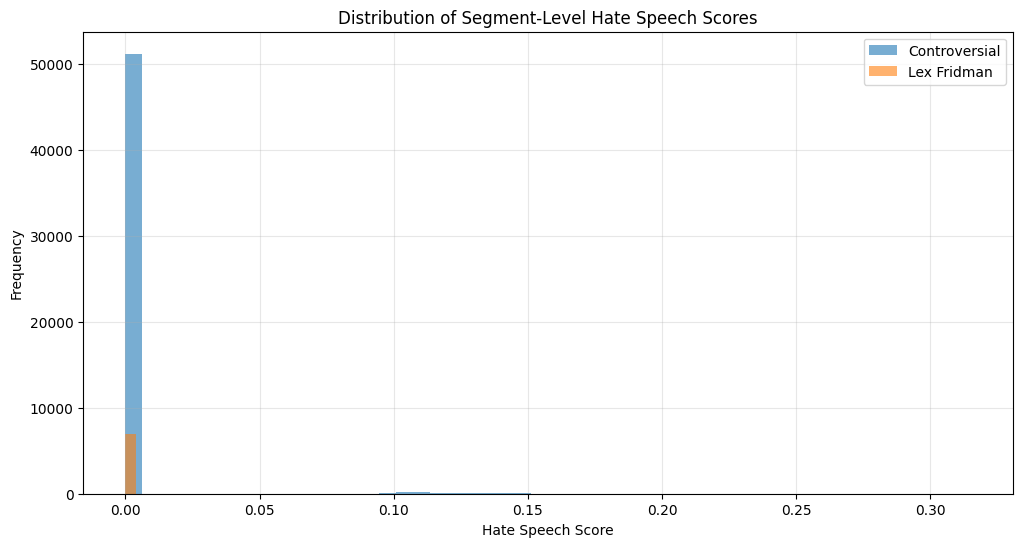

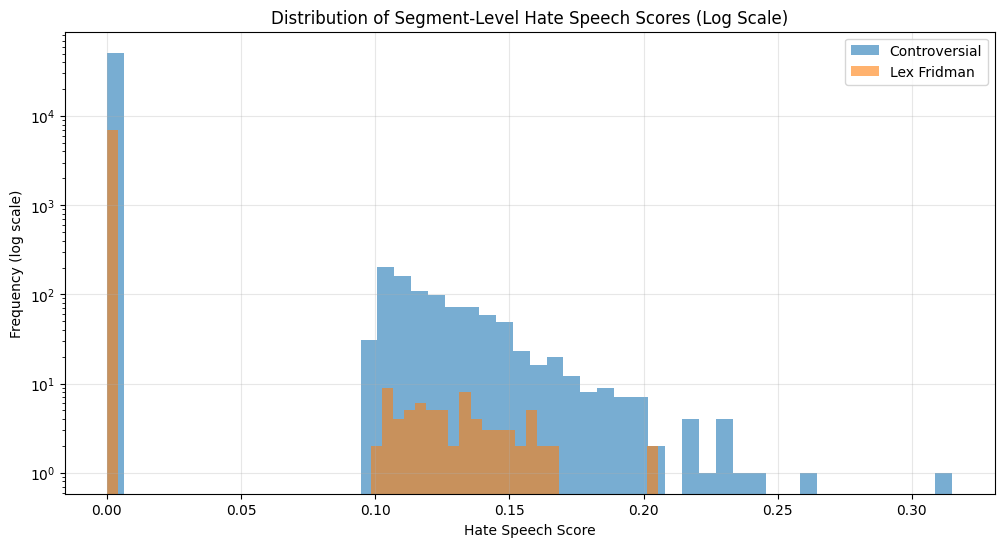

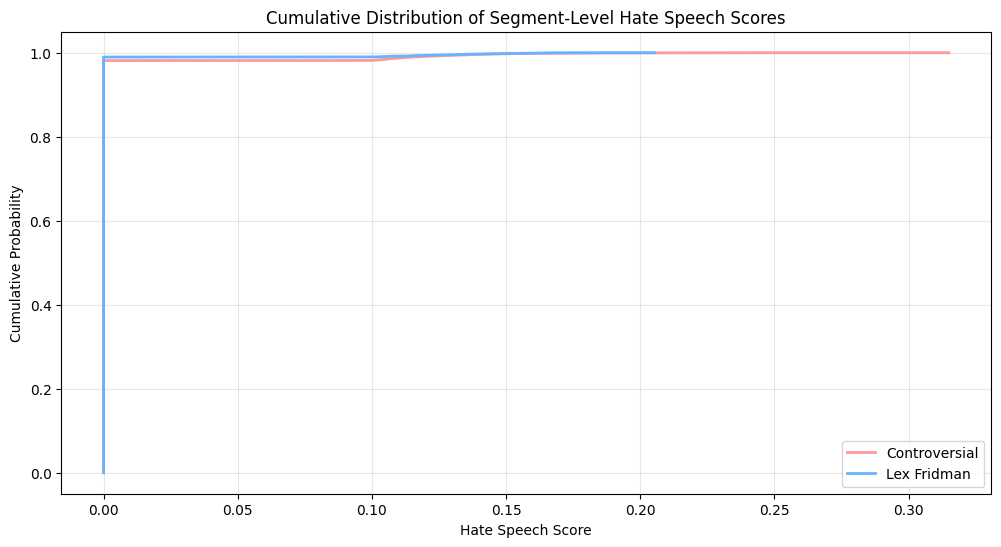


Segment-level statistics for hate speech scores:

Controversial:
  Count: 52185
  Mean: 0.0024
  Median: 0.0000
  Std Dev: 0.0174
  Min: 0.0000
  Max: 0.3151
  25th Percentile: 0.0000
  75th Percentile: 0.0000
  90th Percentile: 0.0000
  95th Percentile: 0.0000
  99th Percentile: 0.1166
  High risk segments (> 0.5): 0 (0.00%)
  Medium risk segments (0.1-0.5): 976 (1.87%)

Lex Fridman:
  Count: 7008
  Mean: 0.0013
  Median: 0.0000
  Std Dev: 0.0134
  Min: 0.0000
  Max: 0.2053
  25th Percentile: 0.0000
  75th Percentile: 0.0000
  90th Percentile: 0.0000
  95th Percentile: 0.0000
  99th Percentile: 0.1017
  High risk segments (> 0.5): 0 (0.00%)
  Medium risk segments (0.1-0.5): 72 (1.03%)


In [17]:
# Create segment-level visualizations and comparisons
import matplotlib.pyplot as plt
import numpy as np

# Save the completed segment dataframes to CSV files
segment_scores_df.to_csv("data/controversial_segment_scores.csv", index=False)
lex_segment_scores_df.to_csv("data/lex_fridman_segment_scores.csv", index=False)

# Create dataframes with platform labels for combined analysis
controversial_segments = pd.DataFrame({
    'platform': ['Controversial'] * len(segment_scores_df),
    'score': segment_scores_df['score']
})

lex_segments = pd.DataFrame({
    'platform': ['Lex Fridman'] * len(lex_segment_scores_df),
    'score': lex_segment_scores_df['score']
})

# Combine segment scores
all_segment_scores = pd.concat([controversial_segments, lex_segments], ignore_index=True)
all_segment_scores.to_csv("data/all_segment_scores.csv", index=False)
print("Saved all segment-level data to CSV files")

# Create a boxplot comparison for segment-level scores
plt.figure(figsize=(10, 6))

# Extract data for each platform
platforms = all_segment_scores['platform'].unique()
segment_data = [all_segment_scores[all_segment_scores['platform'] == platform]['score'] for platform in platforms]

# Create box plot
box = plt.boxplot(segment_data, patch_artist=True, labels=platforms)
colors = ['#ff9999', '#66b3ff']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Segment-Level Hate Speech Score Comparison')
plt.ylabel('Hate Speech Score')
plt.grid(True, alpha=0.3)
plt.show()

# Create histograms to compare segment-level score distributions
plt.figure(figsize=(12, 6))

# Extract data for each platform
for i, platform in enumerate(platforms):
    platform_data = all_segment_scores[all_segment_scores['platform'] == platform]['score']
    # Plot histogram with log scale for y-axis to better see the distribution tail
    plt.hist(platform_data, bins=50, alpha=0.6, label=platform)

plt.title('Distribution of Segment-Level Hate Speech Scores')
plt.xlabel('Hate Speech Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Create a second histogram with log scale for better comparison of tails
plt.figure(figsize=(12, 6))
for i, platform in enumerate(platforms):
    platform_data = all_segment_scores[all_segment_scores['platform'] == platform]['score']
    # Plot histogram with log scale for y-axis
    plt.hist(platform_data, bins=50, alpha=0.6, label=platform)

plt.title('Distribution of Segment-Level Hate Speech Scores (Log Scale)')
plt.xlabel('Hate Speech Score')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Create cumulative distribution function (CDF) plot
plt.figure(figsize=(12, 6))
for i, platform in enumerate(platforms):
    platform_data = all_segment_scores[all_segment_scores['platform'] == platform]['score']
    # Sort the data
    sorted_data = np.sort(platform_data)
    # Get the cumulative probabilities
    p = 1. * np.arange(len(sorted_data)) / (len(sorted_data) - 1)
    # Plot the CDF
    plt.plot(sorted_data, p, label=platform, color=colors[i], linewidth=2)

plt.title('Cumulative Distribution of Segment-Level Hate Speech Scores')
plt.xlabel('Hate Speech Score')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print detailed statistics for segment-level scores
print("\nSegment-level statistics for hate speech scores:")
for platform in all_segment_scores['platform'].unique():
    platform_scores = all_segment_scores[all_segment_scores['platform'] == platform]['score']
    print(f"\n{platform}:")
    print(f"  Count: {len(platform_scores)}")
    print(f"  Mean: {platform_scores.mean():.4f}")
    print(f"  Median: {platform_scores.median():.4f}")
    print(f"  Std Dev: {platform_scores.std():.4f}")
    print(f"  Min: {platform_scores.min():.4f}")
    print(f"  Max: {platform_scores.max():.4f}")
    print(f"  25th Percentile: {platform_scores.quantile(0.25):.4f}")
    print(f"  75th Percentile: {platform_scores.quantile(0.75):.4f}")
    print(f"  90th Percentile: {platform_scores.quantile(0.9):.4f}")
    print(f"  95th Percentile: {platform_scores.quantile(0.95):.4f}")
    print(f"  99th Percentile: {platform_scores.quantile(0.99):.4f}")
    
    # Count high and medium risk segments
    high_risk = len(platform_scores[platform_scores > 0.5])
    high_risk_pct = high_risk / len(platform_scores) * 100
    medium_risk = len(platform_scores[(platform_scores > 0.1) & (platform_scores <= 0.5)])
    medium_risk_pct = medium_risk / len(platform_scores) * 100
    
    print(f"  High risk segments (> 0.5): {high_risk} ({high_risk_pct:.2f}%)")
    print(f"  Medium risk segments (0.1-0.5): {medium_risk} ({medium_risk_pct:.2f}%)")


## Tuning aggregation strategies with a simulation

So far every episode was scored with the default aggregator (`skewness`). But Sentinel ships several "summarize metrics", and which one works best depends on your data. This section runs a small **simulation** (using `sentinel.simulation`) to compare them systematically on our labeled episodes.

Two very different "metrics" are involved, and it helps to keep them separate:

- **Summarize metric (the aggregation):** how an episode's many per-segment scores become a single number. Sentinel offers `skewness`, `mean_of_positives`, `top_k_mean`, `percentile_score`, `softmax_weighted_mean`, and `max_score`. This is *not* a ranking.
- **Evaluation metric:** given one number per episode plus a known label (controversial = 1, Lex Fridman = 0), how well are the two classes separated? Ranking is only one option. The harness reports **three families** so you can tune for whatever matters to you:
  - **Ranking** (`roc_auc`, `recall_at_n`, `rank_ratio`): where do the known-positive episodes land in the leaderboard?
  - **Threshold / classification** (`precision`, `recall`, `f1`): pick a cutoff on the per-episode score and count hits and misses.
  - **Separation / distribution** (`mean_separation`, `cohens_d`, `ks_statistic`): threshold-free distance between the two score distributions.

The expensive part (running the sentence model) is done once by `score_groups`; comparing aggregators and thresholds afterward is cheap.

In [18]:
import random

import pandas as pd

from sentinel.simulation import (
    LabeledGroup,
    score_groups,
    compare_aggregators,
    run_grid_search,
)

# Build "labeled groups": each podcast episode is one group of text segments.
# label = 1 -> controversial (rare / positive class)
# label = 0 -> Lex Fridman  (common / negative class)
controversial_groups = [
    LabeledGroup(name=str(file_path), label=1, observations=group["segment"].tolist())
    for file_path, group in results_df.groupby("file")
]
lex_groups = [
    LabeledGroup(name=str(file_path), label=0, observations=group["segment"].tolist())
    for file_path, group in lex_results_df.groupby("file")
]

# Why 30? It matches the 30 Lex Fridman episodes sampled earlier, so the
# evaluation set is a balanced 30-vs-30 rather than 100-vs-30. Balance changes
# what the metrics mean: top_n defaults to the number of positives, and
# precision/f1 move with the class ratio (roc_auc and recall do not).
# It also caps the runtime, which scales with the number of *segments* rather
# than episodes. Raise both sides together to keep the comparison balanced.
random.seed(0)
controversial_sample = random.sample(
    controversial_groups, min(30, len(controversial_groups))
)
groups = controversial_sample + lex_groups

n_pos = sum(g.label == 1 for g in groups)
n_neg = sum(g.label == 0 for g in groups)
print(f"Built {len(groups)} labeled groups: {n_pos} controversial (label=1), {n_neg} Lex Fridman (label=0)")

# EXPENSIVE STEP (runs the sentence model): score every segment once. The result
# is reused by every aggregator below, so we don't re-encode anything.
scored = score_groups(index, groups, top_k=5, show_progress_bar=True)

# CHEAP STEP: compare all six summarize metrics on the same scores.
comparison = pd.DataFrame(compare_aggregators(scored))
comparison_view = (
    comparison[
        [
            "aggregator",
            "roc_auc",
            "recall_at_n",
            "precision_at_n",
            "rank_ratio",
            "f1",
            "precision",
            "recall",
            "mean_separation",
            "cohens_d",
            "ks_statistic",
        ]
    ]
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
comparison_view

Built 60 labeled groups: 30 controversial (label=1), 30 Lex Fridman (label=0)


,aggregator,roc_auc,recall_at_n,precision_at_n,rank_ratio,f1,precision,recall,mean_separation,cohens_d,ks_statistic
0,skewness,0.894444,0.900000,0.900000,0.440945,0.918033,0.903226,0.933333,0.083502,1.067583,0.833333
1,max_score,0.860000,0.766667,0.766667,0.476998,0.848485,0.777778,0.933333,0.104175,1.792746,0.666667
2,percentile_score,0.852222,0.766667,0.766667,0.485390,0.848485,0.777778,0.933333,0.093693,1.803957,0.666667
3,top_k_mean,0.847778,0.766667,0.766667,0.490228,0.848485,0.777778,0.933333,0.094076,1.756884,0.666667
4,softmax_weighted_mean,0.796667,0.766667,0.766667,0.548223,0.848485,0.777778,0.933333,0.079249,1.715674,0.666667
5,mean_of_positives,0.795556,0.766667,0.766667,0.549534,0.848485,0.777778,0.933333,0.078998,1.714080,0.666667


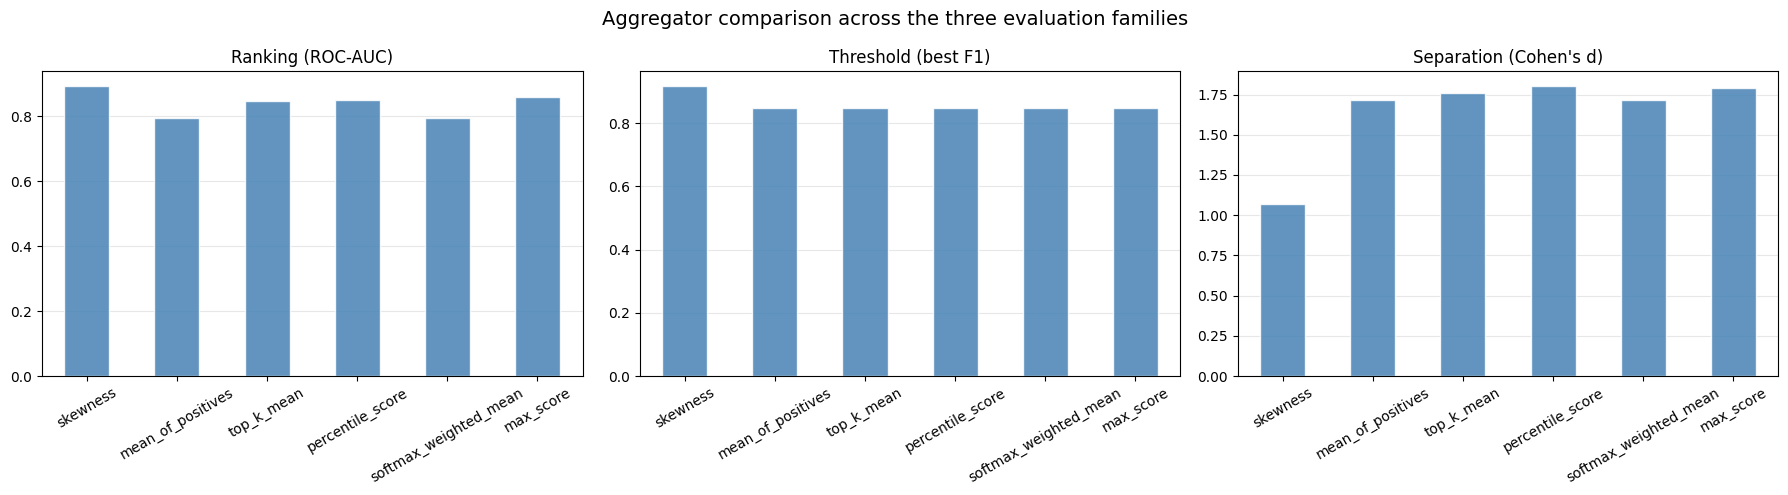

In [19]:
import matplotlib.pyplot as plt

# Show one representative metric from each evaluation family, per aggregator.
# We use separate subplots because the families live on different scales
# (roc_auc and f1 are in [0, 1], while Cohen's d can exceed 1).
families = ["roc_auc", "f1", "cohens_d"]
family_titles = {
    "roc_auc": "Ranking (ROC-AUC)",
    "f1": "Threshold (best F1)",
    "cohens_d": "Separation (Cohen's d)",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, family in zip(axes, families):
    values = comparison.set_index("aggregator")[family]
    values.plot(kind="bar", ax=ax, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(family_titles[family])
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Aggregator comparison across the three evaluation families", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Grid search: sweep top_k (each value re-scores the segments) and the
# per-observation threshold min_score_to_consider (applied cheaply), for every
# aggregator. Returns one row per (top_k, min_score, aggregator) combination.
grid = pd.DataFrame(
    run_grid_search(
        index,
        groups,
        top_k_values=[3, 5, 10],
        min_score_values=[0.0, 0.1, 0.25],
    )
)

# Which single configuration separates the two classes best (by ROC-AUC)?
best = grid.sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("Top configurations by ROC-AUC:")
best[["aggregator", "top_k", "min_score_to_consider", "roc_auc", "f1", "cohens_d"]].head(10)

Top configurations by ROC-AUC:


,aggregator,top_k,min_score_to_consider,roc_auc,f1,cohens_d
0,skewness,5,0.0,0.976667,0.935484,2.755040
1,skewness,3,0.0,0.970000,0.933333,2.669152
2,skewness,10,0.0,0.953333,0.915254,2.471844
3,top_k_mean,3,0.0,0.904444,0.885246,1.833128
4,skewness,5,0.1,0.894444,0.918033,1.067583
5,max_score,3,0.0,0.891111,0.857143,1.714937
6,top_k_mean,5,0.0,0.890000,0.878788,1.714391
7,skewness,3,0.1,0.886667,0.900000,1.170104
8,max_score,3,0.1,0.880000,0.857143,1.721444
9,top_k_mean,3,0.1,0.868889,0.848485,1.631476


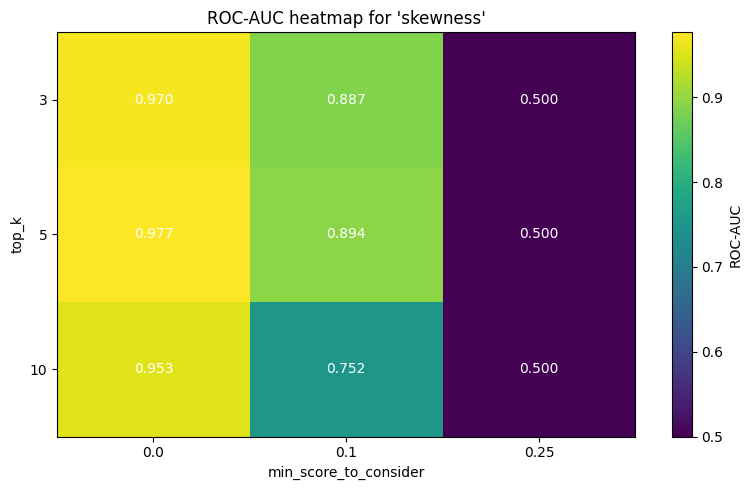

In [21]:
# Heatmap of ROC-AUC over (top_k x min_score_to_consider) for the best aggregator,
# so we can pick a robust configuration rather than a single lucky point.
best_aggregator = best.iloc[0]["aggregator"]
sub = grid[grid["aggregator"] == best_aggregator]
pivot = sub.pivot(index="top_k", columns="min_score_to_consider", values="roc_auc")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("min_score_to_consider")
ax.set_ylabel("top_k")
ax.set_title(f"ROC-AUC heatmap for '{best_aggregator}'")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="ROC-AUC")
plt.tight_layout()
plt.show()

### Reading the results

- The **aggregator comparison** shows how the choice of summarize metric changes how cleanly controversial and Lex Fridman episodes separate. If `skewness` is not the top row, another aggregator may fit this dataset better.
- The three families can disagree: an aggregator can rank well (high `roc_auc`) yet have a modest best-`f1`, or vice versa. Choose the family that matches how you will use the score - triage/ranking (ranking family), a hard yes/no cutoff (threshold family), or distribution monitoring (separation family).
- The **grid search** reports the best `(top_k, min_score_to_consider)` per aggregator, and the heatmap helps you pick a setting that is good across neighboring values (robust) rather than a single lucky cell.

This ties directly into the "wolf in sheep's clothing" appendix below: aggregators such as `skewness`, `top_k_mean`, and `percentile_score` are built to catch a few high-scoring segments hidden inside otherwise benign content - exactly the signal that simple averaging would wash out.

### What we found

Three conclusions held up on this dataset, and one trap is worth avoiding.

**Skewness is the right default.** After the grid search, the highest-scoring configurations are all `skewness`, and tuning lifts it clearly above what any aggregator reaches at the out-of-the-box settings. Sentinel's default choice is a good one for content shaped like this - long, mostly benign transcripts with occasional concentrated spikes.

**The noise floor deserves a sweep, not an assumption.** `min_score_to_consider` affects `skewness` far more than the other aggregators, and there is a concrete reason. `skewness` computes `(mean - median) / std` over the *entire* array of segment scores, zeros included, while the other five first filter with `scores[scores > 0]`. Raising the floor therefore reshapes the distribution that `skewness` sees, whereas for the others it simply removes inputs. Its best value also interacts with `top_k`, so sweep the two together rather than tuning either on its own.

**Do not over-read small gaps.** With 30 episodes per class, differences of a few thousandths of ROC-AUC sit inside the margin of error: re-running against a different sample can reorder the leading aggregators. Read the table as "this group is clearly ahead of that group" rather than as an exact ranking, and prefer a configuration surrounded by other strong cells in the heatmap over the single best cell, which may just be lucky. Raising the episode counts is the way to tighten this up.

## Conclusion and Key Findings

In this notebook, we've built and evaluated a hate speech detection system using Sentinel with minimal training data. The key aspects of our approach include:

1. **Efficient Model Creation**: We constructed a hate speech detection model using only ~1,500 extremist quotes from SPLC as positive examples, balanced against ~15,000 neutral Lex Fridman podcast segments. This demonstrates Sentinel's ability to work effectively with limited training data.

2. **Cross-Dataset Evaluation**: By testing on a controversial podcast content (not seen during training) and comparing against Lex Fridman episodes, we validated the model's generalization capabilities and resistance to domain-specific biases.

3. **Multi-level Analysis**: We analyzed content at both segment level (individual text chunks) and episode level (aggregated scores using skewness), showing how patterns of concerning language emerge even when individual segments might not cross thresholds.

4. **Statistical Validation**: The distributions and percentile analysis demonstrate clear differentiation between the two content sources, with the other podcast showing significantly higher percentages of high-risk segments compared to Lex Fridman's podcast.

5. **Practical Application**: The CSV exports and visualization tools enable further analysis and potential integration into content moderation workflows.

This methodology showcases Sentinel's capability to detect rare class patterns in text with minimal examples, highlighting its potential for practical applications in online safety, content moderation, and harmful content detection across diverse platforms.

## Appendix: Detecting the "Wolf in Sheep's Clothes" - The Power of Skewness

Our analysis reveals an important pattern in how harmful content manifests across different sources, demonstrating Sentinel's ability to detect what we might call the "wolf in sheep's clothes" phenomenon.

### Understanding the Distribution Patterns

Looking at the segment-level histograms and statistics, we observe:

1. **Low Central Tendency in Both Sources**: Both Lex Fridman podcasts and the other podcast have segment score distributions with relatively low central tendency (mean/median) - the majority of content segments from both sources receive low hate speech scores.

2. **Critical Difference in Distribution Shape**: While both distributions have similar centers, the other podcast' distribution is notably **right-skewed with a heavy tail** - showing a relatively small number of highly toxic segments that score much higher than the average content.

3. **The "Hidden Toxicity" Problem**: This pattern represents a common challenge in content moderation - harmful content often appears as occasional "spikes" within otherwise benign material. Simple averaging methods would dilute these spikes, potentially missing concerning content.

### How Sentinel's Episode-Level Scoring Captures This Pattern

Sentinel's methodology effectively addresses this challenge through:

1. **Statistical Sensitivity to Skewness**: Rather than simple averaging, the episode-level scores account for distribution shape, giving higher weight to right-skewed distributions where even a few high-scoring segments exist.

2. **Capturing Rare but Significant Signals**: This approach successfully identifies content sources that occasionally "show their teeth" with harmful rhetoric, even when such rhetoric represents a small percentage of the total content.

3. **Practical Moderation Value**: The resulting episode-level scores place the other podcast episodes significantly higher than Lex Fridman episodes, creating a clear prioritization signal for content moderation efforts.

This approach demonstrates why robust hate speech detection requires attention not just to average content characteristics, but to distribution patterns that might reveal occasional but significant harmful content within otherwise unremarkable material.

# Appendix: What's new in Sentinel 2.0

One part of 2.0 is already demonstrated above, on real data: **Tuning aggregation
strategies with a simulation** uses the `sentinel.simulation` harness, which 2.0
introduced. Treat that section as the worked example - it compares aggregators on
thousands of real podcast segments, which is the comparison that actually tells you
something.

This appendix covers the rest, and fills in the parts of the harness that section does
not reach (`evaluate_groups`, `DEFAULT_AGGREGATORS`, and the new index sweep axes).

It is deliberately **self-contained** - it builds its own small index from a handful of
example sentences and does not depend on the data-loading cells above, so you can run it
on its own in a few seconds. The flip side is that its fixture is too easy to separate
aggregators meaningfully; for that, read the section above. The timings here are
illustrations of shape rather than benchmarks, and the advantages grow with real corpora
where encoding dominates everything else.

Full write-up and migration notes: [V2_FEATURES.md](../V2_FEATURES.md).

In [22]:
import tempfile
import time
from pathlib import Path

import pandas as pd

import sentinel
from sentinel import SentinelLocalIndex
from sentinel.simulation import (
    LabeledGroup,
    compare_aggregators,
    encode_observations,
    evaluate_groups,
    run_grid_search,
    score_groups,
)

print(f"Sentinel version: {sentinel.__version__}")

Sentinel version: 2.0.0


## 1. `from_texts()` - build an index in one call

The **Build The Indexes** section above does this by hand: load the model, keep the
scaling function, encode both sides, remember `normalize_embeddings=True`, keep the
corpus, then construct the index.

Two of those steps fail *silently* when skipped. Without normalisation the similarity
maths quietly returns wrong numbers, and without the corpus you lose explanations.
Neither raises, and neither warns - you simply get worse results and never find out.
`from_texts()` does the whole recipe, inside the library, where it is tested.

In [23]:
# A few examples of the rare class we want to catch, and of ordinary conversation.
HATEFUL = [
    "they are vermin and need to be removed from our country",
    "those people are subhuman and do not deserve any rights",
    "we must cleanse the nation of their filthy kind",
    "they are a disease infecting our society and must be purged",
    "their race has always been inferior and violent by nature",
    "we should drive every last one of them out by force",
    "the world would be better off without their bloodline",
    "they breed like rats and are ruining everything we built",
]
ORDINARY = [
    "the weather has been lovely this week",
    "i really enjoyed that documentary last night",
    "we should meet for coffee sometime soon",
    "the train was delayed again this morning",
    "she gave a thoughtful talk about urban planning",
    "my neighbour is teaching me to bake bread",
    "the new library opens on the corner next month",
    "he spent the weekend repairing his bicycle",
    "they are renovating the community centre this spring",
    "the match ended in a draw after extra time",
    "i finally finished the book you lent me",
    "the bakery on the high street changed hands",
    "we planted tomatoes along the back fence",
    "the bus route is being extended next year",
    "there is a food market every second saturday",
    "my sister is moving house in the autumn",
]

# Half of each list goes into the index; the rest is held out for evaluation below, so we
# never score an example against itself.
index_positives, held_out_hateful = HATEFUL[:6], HATEFUL[6:]
index_negatives, held_out_ordinary = ORDINARY[:6], ORDINARY[6:]

demo_index = SentinelLocalIndex.from_texts(
    positive_texts=index_positives,
    negative_texts=index_negatives,
    model_name="sentence-transformers/all-MiniLM-L6-v2",
)

print(f"positives: {tuple(demo_index.positive_embeddings.shape)}")
print(f"negatives: {tuple(demo_index.negative_embeddings.shape)}")
print(f"corpus kept automatically: {demo_index.positive_corpus is not None}")
print(f"normalisation applied:     {demo_index.encoding_kwargs['normalize_embeddings']}")

positives: (6, 384)
negatives: (6, 384)
corpus kept automatically: True
normalisation applied:     True


## 2. The corpus survives a save/load round trip

In 1.0, `save()` wrote only the embeddings and the config. After any reload the corpus
was gone, so explanations reported the *row number* of a match rather than the sentence
that caused it - useful to a machine, useless to a reviewer.

2.0 writes a `corpus.json` beside the embeddings, so an explanation can name the text.

In [24]:
with tempfile.TemporaryDirectory() as tmp:
    demo_index.save(
        path=tmp, encoder_model_name_or_path="sentence-transformers/all-MiniLM-L6-v2"
    )
    print("files written:", sorted(p.name for p in Path(tmp).iterdir()))

    # A seed makes the load reproducible, which is also new in 2.0: without it the
    # negative downsampling differed on every load and the same text scored differently.
    reloaded = SentinelLocalIndex.load(
        path=tmp, negative_to_positive_ratio=None, seed=42
    )

result = reloaded.calculate_rare_class_affinity(
    ["those people are a plague on this country"]
)
explanation = next(iter(result.explanations.values()))

print("\nWhy that text scored as it did - the nearest examples, named rather than numbered:")
for neighbor in explanation["neighbors"][:3]:
    print(f"  {neighbor['sign']} {neighbor['scaled_score']:.3f}  {neighbor['neighbor']}")

files written: ['corpus.json', 'embeddings.safetensors', 'sentinel_local_index_config.json']



Why that text scored as it did - the nearest examples, named rather than numbered:
  + 0.540  they are a disease infecting our society and must be purged
  + 0.424  those people are subhuman and do not deserve any rights
  + 0.397  we must cleanse the nation of their filthy kind


`load_corpus` reads those texts back on their own, without loading the embeddings -
handy for checking what a saved index actually contains before you trust it. It returns
`(None, None)` for an index saved before 2.0, which is how the shipped example index
behaves and why its explanations would show row numbers.

In [25]:
from sentinel.io import load_corpus

with tempfile.TemporaryDirectory() as tmp:
    demo_index.save(
        path=tmp, encoder_model_name_or_path="sentence-transformers/all-MiniLM-L6-v2"
    )
    saved_positive, saved_negative = load_corpus(path=tmp)

print(f"positives stored: {len(saved_positive)}   negatives stored: {len(saved_negative)}")
print(f"first positive:   {saved_positive[0]}")

# The index shipped with this repository predates corpus support.
print(f"\nshipped example index: {load_corpus(path='hate_speech_model')}")

positives stored: 6   negatives stored: 6
first positive:   they are vermin and need to be removed from our country

shipped example index: (None, None)


## 3. `subsample()` - resize an index without re-encoding

Encoding a sentence produces the same numbers regardless of which index it ends up in,
so a small index is just a large one with rows removed. Before 2.0, trying a smaller
index meant encoding the whole corpus from scratch.

The example index shipped with this repository is a realistic size, so it shows the
point better than our six-sentence one.

In [26]:
shipped = SentinelLocalIndex.load(
    path="hate_speech_model", negative_to_positive_ratio=None, seed=42
)

start = time.perf_counter()
smaller = shipped.subsample(n_positive=500, neg_to_pos_ratio=5.0, seed=42)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"original: {shipped.positive_embeddings.shape[0]:,} positives / "
      f"{shipped.negative_embeddings.shape[0]:,} negatives")
print(f"resized:  {smaller.positive_embeddings.shape[0]:,} positives / "
      f"{smaller.negative_embeddings.shape[0]:,} negatives")
print(f"took {elapsed_ms:.1f} ms - no encoding involved")

# The original is untouched, which is what makes it safe to loop over sizes. If each
# call shrank the receiver, run two would start from run one's leftovers.
print(f"\noriginal still intact: {shipped.positive_embeddings.shape[0]:,} positives")

original: 1,516 positives / 15,160 negatives
resized:  500 positives / 2,500 negatives
took 2.2 ms - no encoding involved

original still intact: 1,516 positives


## 4. The tuning harness, cheapest entry point first

`sentinel.simulation` arrived in 2.0 and is what the **Tuning aggregation strategies**
section above runs on. That section uses the two convenience entry points; this one shows
the full ladder, including the single-aggregator step underneath them.

The harness is layered by cost. Scoring runs the model and is the only expensive step, so
you do it once and then evaluate as many ways as you like for free:

| Function | What it does | Cost |
|---|---|---|
| `score_groups` | Scores every observation in every group | runs the model |
| `evaluate_groups` | Collapses each group to one number with **one** aggregator, then measures the separation | free |
| `compare_aggregators` | Runs `evaluate_groups` once per aggregator on the same scores | free |
| `run_grid_search` | Wraps all of the above and sweeps hyperparameters | re-scores per `top_k` |

Two different things get called "metrics" here. The **summarize metric** (the
aggregator) is *how* a group's many scores become one number, and it is what you sweep.
The **evaluation metric** is *how good* that separation is, and you do not choose one -
every row reports all three families.

In [27]:
from sentinel.simulation import DEFAULT_AGGREGATORS

# Four "sources" built from the sentences held out above. The two positive sources are
# mostly ordinary chatter with a couple of hateful lines mixed in - the realistic
# pattern, and the one the appendix on skewness above is about.
groups = [
    LabeledGroup(
        name="hateful_a", label=1,
        observations=held_out_ordinary[:9] + held_out_hateful[:1],
    ),
    LabeledGroup(
        name="hateful_b", label=1,
        observations=held_out_ordinary[1:] + held_out_hateful[1:],
    ),
    LabeledGroup(name="ordinary_a", label=0, observations=held_out_ordinary[:10]),
    LabeledGroup(name="ordinary_b", label=0, observations=held_out_ordinary),
]
for group in groups:
    print(f"  {group.name:11} label={group.label}  {len(group.observations)} observations")

print("\nbuilt-in summarize metrics:", ", ".join(DEFAULT_AGGREGATORS))

# Score once...
scored_once = score_groups(demo_index, groups, top_k=3)
print(f"\nscored {len(scored_once)} groups; "
      f"{scored_once[0].name} has {len(scored_once[0].observation_scores)} observation scores")

# ...then evaluate with a single aggregator, for free.
row = evaluate_groups(
    scored_once, DEFAULT_AGGREGATORS["skewness"], aggregator_name="skewness"
)
print(f"\nskewness alone -> roc_auc={row['roc_auc']:.2f}  f1={row['f1']:.2f}")
print(f"  ranking:    roc_auc={row['roc_auc']:.2f}  recall_at_n={row['recall_at_n']:.2f}")
print(f"  threshold:  precision={row['precision']:.2f}  recall={row['recall']:.2f}")
print(f"  separation: mean_separation={row['mean_separation']:.3f}  ks={row['ks_statistic']:.2f}")

# n_positive here counts positive GROUPS, not index rows - the distinction that the
# index_ prefix exists to protect.
print(f"\nn_groups={row['n_groups']}  n_positive={row['n_positive']} (positive sources)")

  hateful_a   label=1  10 observations
  hateful_b   label=1  10 observations
  ordinary_a  label=0  10 observations
  ordinary_b  label=0  10 observations

built-in summarize metrics: skewness, mean_of_positives, top_k_mean, percentile_score, softmax_weighted_mean, max_score

scored 4 groups; hateful_a has 10 observation scores

skewness alone -> roc_auc=1.00  f1=1.00
  ranking:    roc_auc=1.00  recall_at_n=1.00
  threshold:  precision=1.00  recall=1.00
  separation: mean_separation=0.333  ks=1.00

n_groups=4  n_positive=2 (positive sources)


## 5. Grid search over the index itself

`run_grid_search` can now sweep index size and negative ratio, not just `top_k` and the
per-observation threshold. Index size is usually the highest-leverage knob, and
`subsample()` is what makes exploring it affordable.

Same four sources as above, so the only thing changing is the index.

In [28]:
grid = pd.DataFrame(
    run_grid_search(
        demo_index,
        groups,
        n_positive_values=[3, 6],       # new in 2.0: index size
        neg_to_pos_ratios=[0.5, 1.0],   # new in 2.0: index balance
        top_k_values=[1, 3],
        min_score_values=[0.0],
        index_seed=42,                  # reproducible index configurations
    )
)

configurations = grid[["index_n_positive", "index_neg_to_pos_ratio"]].drop_duplicates()
print(f"\n{len(grid)} rows across {len(configurations)} index configurations")
grid[[
    "aggregator", "index_n_positive", "index_neg_to_pos_ratio",
    "index_n_positive_actual", "index_n_negative_actual", "top_k", "roc_auc",
]].head(6)


48 rows across 4 index configurations


,aggregator,index_n_positive,index_neg_to_pos_ratio,index_n_positive_actual,index_n_negative_actual,top_k,roc_auc
0,skewness,3,0.5,3,1,1,1.0
1,mean_of_positives,3,0.5,3,1,1,1.0
2,top_k_mean,3,0.5,3,1,1,1.0
3,percentile_score,3,0.5,3,1,1,1.0
4,softmax_weighted_mean,3,0.5,3,1,1,1.0
5,max_score,3,0.5,3,1,1,1.0


### Two details in that table worth pausing on

**Requested versus actual.** A request is *clipped* when the index holds fewer examples
than you asked for, so `index_n_positive` (what you asked for) and
`index_n_positive_actual` (what you got) can differ. Without the actual counts, two rows
can look like a genuine size sweep while describing nearly the same index.

**Why every index column is prefixed.** `evaluate_groups` already returns an
`n_positive`, meaning *the number of positive groups in your evaluation set*. That is an
entirely different number from the index size, and the two briefly shared one name - so
the index size silently overwrote the group count. Writing a column twice now raises
rather than overwriting.

In [29]:
# Same rows, two unrelated meanings, both surviving side by side.
#   n_positive       -> how many of our four sources are labelled positive (2)
#   index_n_positive -> how many positive examples the index was built with (3 or 6)
grid[["n_positive", "index_n_positive", "index_n_positive_actual"]].drop_duplicates()

,n_positive,index_n_positive,index_n_positive_actual
0,2,3,3
24,2,6,6


## 6. Observations are encoded once per sweep

An observation's embedding depends on the **encoder**, never on the index it is scored
against - and a subsampled index shares its parent's model. So re-encoding the same text
on every pass was recomputing identical numbers.

2.0 hoists the encoding out of the loops. The results are unchanged; only the time is.

In [30]:
sweep = dict(
    n_positive_values=[3, 6],
    neg_to_pos_ratios=[0.5, 1.0],
    top_k_values=[1, 2, 3],
    min_score_values=[0.0],
    index_seed=42,
)

start = time.perf_counter()
uncached = run_grid_search(demo_index, groups, cache_observation_embeddings=False, **sweep)
uncached_seconds = time.perf_counter() - start

start = time.perf_counter()
cached = run_grid_search(demo_index, groups, cache_observation_embeddings=True, **sweep)
cached_seconds = time.perf_counter() - start

print(f"re-encoding on every pass: {uncached_seconds:.2f}s")
print(f"encoding once:             {cached_seconds:.2f}s")
print(f"saving:                    {uncached_seconds / cached_seconds:.1f}x")
print(f"identical results:         {pd.DataFrame(uncached).equals(pd.DataFrame(cached))}")

re-encoding on every pass: 0.62s
encoding once:             0.09s
saving:                    6.6x
identical results:         True


The saving grows with the grid, because the single encoding pass is amortised over more
scoring passes. Pass `cache_observation_embeddings=False` if memory is tight - the cache
holds one embedding per observation.

You can also hold the embeddings yourself, which is what you want when scoring the same
observations against several unrelated indices.

In [31]:
embeddings = encode_observations(demo_index, groups)
print(f"cached embeddings for {len(embeddings)} groups")

# The same embeddings, scored against two different indices built from one encoder.
comparisons = []
for name, candidate in (
    ("full", demo_index),
    ("half-size", demo_index.subsample(n_positive=3, seed=42)),
):
    scored = score_groups(candidate, groups, top_k=3, observation_embeddings=embeddings)
    for row in compare_aggregators(scored):
        comparisons.append({"index": name, **row})

pd.DataFrame(comparisons).pivot(
    index="aggregator", columns="index", values="roc_auc"
)

cached embeddings for 4 groups


index,full,half-size
aggregator,,
max_score,1.0,1.0
mean_of_positives,1.0,1.0
percentile_score,1.0,1.0
skewness,1.0,1.0
softmax_weighted_mean,1.0,1.0
top_k_mean,1.0,1.0


At the lowest level this is just a new argument on `calculate_rare_class_affinity`.
Everything above is built on it, and you can reach for it directly when scoring the same
text repeatedly. Sentinel checks that the embeddings line up with the text, because
silently pairing an observation with the wrong vector would be far worse than an error.

In [32]:
texts = ["those people are a plague on this country", "the bus route changed again"]
vectors = demo_index.sentence_model.encode(texts, **demo_index.encoding_kwargs)

inline = demo_index.calculate_rare_class_affinity(texts)
reused = demo_index.calculate_rare_class_affinity(texts, vectors)
print(f"same scores either way: {inline.observation_scores == reused.observation_scores}")
for observation, score in reused.observation_scores.items():
    print(f"  {score:.3f}  {observation}")

# A mismatch is refused rather than quietly scoring against the wrong vectors.
try:
    demo_index.calculate_rare_class_affinity(texts, vectors[:1])
except ValueError as error:
    print(f"\nrefused: {error}")

same scores either way: True
  0.202  those people are a plague on this country
  0.000  the bus route changed again

refused: sample_embeddings has 1 rows but text_samples has 2 entries. Scoring them together would pair each observation with the wrong embedding, so refusing to continue.


Every aggregator separates this example perfectly, which tells you the example is easy
rather than that the aggregators are equivalent - with four sources and a vocabulary this
clean, there is nothing to distinguish them. The comparison only becomes interesting on
real data, which is what the **Tuning aggregation strategies** section above does.

What this cell does show is the mechanism: one set of embeddings, computed once, scored
against two different indices without re-encoding anything.

## 7. Putting it together: a real sweep on the podcast data

Sections 1-6 used a toy fixture so they would run in seconds. This one uses the real
evaluation set built earlier in the notebook - **30 controversial episodes against 30
Lex Fridman episodes, 22,885 segments in total** - and needs the cells above to have
been run.

The **Tuning aggregation strategies** section above could only sweep `top_k` and the
threshold, because in 1.0 those were the only knobs that did not require rebuilding the
index. 2.0 adds the index itself as an axis, so we can ask a question that was
previously impractical: *how much does index size and balance actually matter?*

### Why this is affordable now

Encoding 22,885 segments takes about two minutes. Scoring them against an index, once
they are embedded, takes about a second and a half.

Before 2.0 every configuration paid the encoding cost again, so a 27-configuration sweep
meant 27 encodes. That is the difference between a coffee break and most of an hour.

In [33]:
import time

from sentinel.simulation import encode_observations

total_segments = sum(len(g.observations) for g in groups)
print(f"{len(groups)} episodes, {total_segments:,} segments")

start = time.perf_counter()
cached = encode_observations(index, groups)
encode_seconds = time.perf_counter() - start

start = time.perf_counter()
score_groups(index, groups, top_k=5, observation_embeddings=cached)
pass_seconds = time.perf_counter() - start

passes = 3 * 3 * 3  # sizes x ratios x top_k, the sweep below
print(f"\nencode once:        {encode_seconds:6.1f}s")
print(f"one scoring pass:   {pass_seconds:6.1f}s")
print(f"\n{passes}-configuration sweep")
print(f"  re-encoding each time: {passes * (encode_seconds + pass_seconds) / 60:5.1f} min")
print(f"  encoding once:         {(encode_seconds + passes * pass_seconds) / 60:5.1f} min")

60 episodes, 22,885 segments



encode once:         117.0s
one scoring pass:      1.4s

27-configuration sweep
  re-encoding each time:  53.3 min
  encoding once:           2.6 min


### The sweep

Three index sizes, three negative ratios, three `top_k` values and two thresholds,
across all six aggregators. The index is rebuilt by `subsample()` for each
(size, ratio) pair, which costs milliseconds.

In [34]:
start = time.perf_counter()
grid = pd.DataFrame(
    run_grid_search(
        index,
        groups,
        n_positive_values=[250, 750, 1516],   # 1516 is the whole index
        neg_to_pos_ratios=[1.0, 5.0, 10.0],
        top_k_values=[3, 5, 10],
        min_score_values=[0.0, 0.1],
        index_seed=42,
    )
)
print(f"{len(grid)} rows in {time.perf_counter() - start:.0f}s\n")

best = grid.sort_values("roc_auc", ascending=False)
best[[
    "aggregator", "index_n_positive", "index_neg_to_pos_ratio",
    "index_n_negative_actual", "top_k", "min_score_to_consider", "roc_auc", "f1",
]].head(8)

324 rows in 148s



,aggregator,index_n_positive,index_neg_to_pos_ratio,index_n_negative_actual,top_k,min_score_to_consider,roc_auc,f1
288,skewness,1516,10.0,15160,3,0.0,0.995556,0.966667
72,skewness,250,10.0,2500,3,0.0,0.987778,0.949153
192,skewness,750,10.0,7500,5,0.0,0.986667,0.935484
84,skewness,250,10.0,2500,5,0.0,0.985556,0.947368
312,skewness,1516,10.0,15160,10,0.0,0.985556,0.937500
180,skewness,750,10.0,7500,3,0.0,0.985556,0.967742
300,skewness,1516,10.0,15160,5,0.0,0.984444,0.952381
264,skewness,1516,5.0,7580,5,0.0,0.982222,0.949153


### What each axis is worth

Averaging over everything else shows which knobs move the needle. The `max` column
matters as much as the `mean`: a setting can be poor on average yet contain the single
best configuration.

In [35]:
for axis in ("index_n_positive", "index_neg_to_pos_ratio", "top_k", "aggregator"):
    summary = (
        grid.groupby(axis)["roc_auc"]
        .agg(["mean", "max"])
        .round(3)
        .sort_values("mean", ascending=False)
    )
    print(f"--- {axis} ---")
    print(summary.to_string())
    print()

--- index_n_positive ---
                   mean    max
index_n_positive              
1516              0.791  0.996
750               0.759  0.987
250               0.718  0.988

--- index_neg_to_pos_ratio ---
                         mean    max
index_neg_to_pos_ratio              
1.0                     0.773  0.939
5.0                     0.767  0.982
10.0                    0.727  0.996

--- top_k ---
        mean    max
top_k              
3      0.797  0.996
5      0.771  0.987
10     0.700  0.986

--- aggregator ---
                        mean    max
aggregator                         
top_k_mean             0.809  0.890
max_score              0.794  0.871
skewness               0.765  0.996
percentile_score       0.737  0.919
softmax_weighted_mean  0.716  0.931
mean_of_positives      0.715  0.934



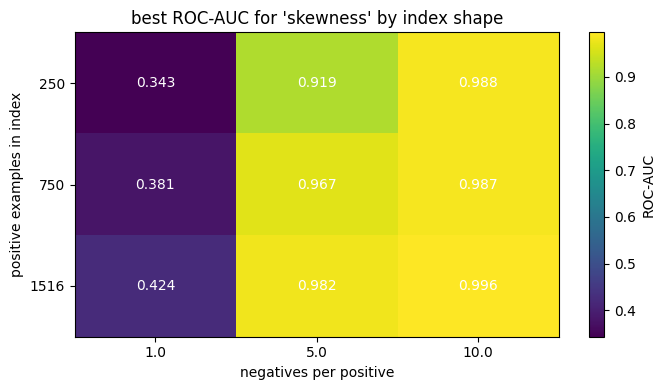

In [36]:
# How index size and balance interact, for the aggregator that wins overall.
winner = best.iloc[0]["aggregator"]
sub = grid[(grid["aggregator"] == winner) & (grid["min_score_to_consider"] == 0.0)]
pivot = sub.pivot_table(
    index="index_n_positive", columns="index_neg_to_pos_ratio", values="roc_auc", aggfunc="max"
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [str(i) for i in pivot.index])
ax.set_xlabel("negatives per positive")
ax.set_ylabel("positive examples in index")
ax.set_title(f"best ROC-AUC for '{winner}' by index shape")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="ROC-AUC")
plt.tight_layout()
plt.show()

### Conclusion

**A bigger index is reliably better.** Mean ROC-AUC climbs with every step up in size -
250, then 750, then the full 1,516 positives - and the single best configuration uses
the whole index. There is no plateau within this range, which suggests the index is if
anything still too small.

**Fewer neighbours beat more.** `top_k=3` wins on both mean and max, and performance
falls off steadily at 5 and 10. Widening the neighbourhood pulls in weaker matches that
dilute the signal.

**Balance is the subtle one.** Averaged across everything, a 1:1 ratio looks best and
10:1 looks worst - yet the single best configuration in the whole sweep uses 10:1. More
negatives help the aggregator that can exploit them and hurt the ones that cannot, so
the average hides the effect entirely.

**The same trap catches the aggregator.** Ranked by *average* ROC-AUC, `top_k_mean`
comes first and `skewness` only third. Ranked by *best achievable*, `skewness` is far
ahead of everything else. In other words skewness is the most configuration-sensitive
aggregator: mediocre when badly tuned, and the clear winner when tuned well.

That is the argument for sweeping rather than picking a default. Choosing the aggregator
by its average would have selected `top_k_mean` and left roughly a tenth of a point of
ROC-AUC on the table - and it is exactly the kind of interaction you cannot see without
varying the index alongside everything else, which is what 2.0 makes cheap enough to do.

## Summary

| Feature | What it replaces |
|---|---|
| `from_texts()` | An eight-step manual build, two steps of which fail silently |
| `subsample()` | Re-encoding the whole corpus to try a smaller index |
| Index sweep axes | Only being able to sweep `top_k` and the threshold |
| Cached observation embeddings | Re-encoding identical text on every pass |
| Persisted corpus | Explanations degrading to row numbers after a reload |
| Seeded `load()` | A saved index scoring differently on every load |

One caveat on the numbers above: this appendix uses a deliberately tiny example set so it
runs in seconds. Treat the timings as illustrations of the shape of the improvement
rather than as benchmarks - on a real corpus the encoding cost dominates far more, so the
savings are correspondingly larger.